# 04 — Experiment C: Hard Character Mining

หา "ตัวอักษรยาก" จาก confusion matrix ของโมเดลจริง (ไม่ได้กำหนดคู่ไว้ล่วงหน้า)
แล้ว fine-tune ใหม่โดยสุ่มคลาสยากบ่อยขึ้น เพื่อดูว่า error ของตัวที่ยากลดลงไหม

```
Baseline -> Confusion Matrix -> Hard Character Set -> Weighted Sampling -> Fine-tune -> เทียบผล
```

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.utils.common import load_config, thai_char, save_json, RESULTS_DIR
from src.datasets.thai_chars import load_data

plt.rcParams["figure.dpi"] = 110
try:
    plt.rcParams["font.family"] = "Thonburi"   # ฟอนต์ไทยที่มากับ macOS
except Exception:
    pass
print("ROOT:", ROOT)

ROOT: /Users/thiya/Documents/GitHub/Project-1-Thai-Character-Number-Recognition


In [2]:
from src.training.run_experiment import prepare, run_hard_character
from src.evaluation import hard_chars as hc

cfg = load_config(ROOT / "configs" / "baseline.yaml")
print("โมเดล:", cfg["model"], "| เกณฑ์ hard character: F1 <", cfg["hard_f1_threshold"])

โมเดล: mobilenet_v3_small | เกณฑ์ hard character: F1 < 0.9


## รันจริง

เทรน 2 รอบ (baseline + fine-tune) ใช้เวลาราว 1–2 ชั่วโมง
ผลอยู่ที่ `experiments/hard_character/` และ `results/tables/hard_character.csv`

In [3]:
data = prepare(cfg)
rows = run_hard_character(cfg, data)
rows

ใช้ cache research_cache_96.npz: 163155 รูป
  ตัดคลาสที่มีตัวอย่างน้อยกว่า 2: 163×1, 177×1, 208×1

=== รอบที่ 1: baseline ===
[mobilenet_v3_small | aug=standard] train 49912 | val 6239 | 81 classes | 1.6M params | mps
    ep1 step 0/389 loss 4.5766
    ep1 step 200/389 loss 1.0226
  epoch 1 train_loss 1.6912 train_acc 0.7492 sec 47.9510 val_acc 0.9328
    ep2 step 0/389 loss 0.8798
    ep2 step 200/389 loss 0.8289
  epoch 2 train_loss 0.8401 train_acc 0.9797 sec 43.7067 val_acc 0.9854
    ep3 step 0/389 loss 0.7874
    ep3 step 200/389 loss 0.7980
  epoch 3 train_loss 0.8114 train_acc 0.9853 sec 52.1314 val_acc 0.9828
    ep4 step 0/389 loss 0.8036
    ep4 step 200/389 loss 0.7959
  epoch 4 train_loss 0.7993 train_acc 0.9883 sec 60.9905 val_acc 0.9894
    ep5 step 0/389 loss 0.7784
    ep5 step 200/389 loss 0.7736
  epoch 5 train_loss 0.7919 train_acc 0.9900 sec 67.6290 val_acc 0.9889
    ep6 step 0/389 loss 0.7770
    ep6 step 200/389 loss 0.7958
  epoch 6 train_loss 0.7860 train_acc 

[{'stage': 'baseline',
  'accuracy': 0.9929,
  'macro_f1': 0.9813,
  'hard_mean_f1': 0.0},
 {'stage': 'finetuned',
  'accuracy': 0.9814,
  'macro_f1': 0.9638,
  'hard_mean_f1': 0.0}]

## Confusion matrix ของ baseline

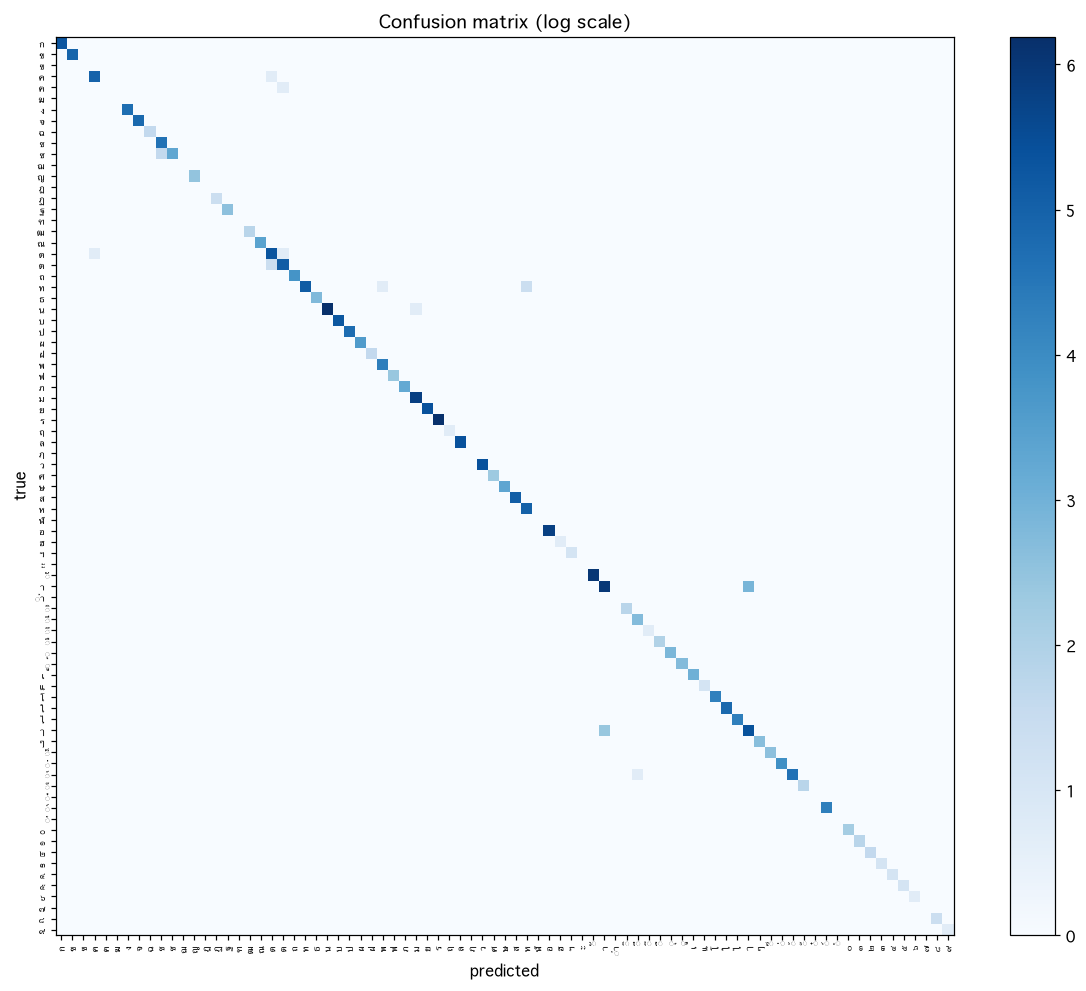

In [4]:
cm = np.load(ROOT / "experiments" / "hard_character" / "baseline" / "confusion.npy")
plt.figure(figsize=(11, 9))
plt.imshow(np.log1p(cm), cmap="Blues")
ticks = range(data.n_classes)
plt.xticks(ticks, [thai_char(c) for c in data.classes], fontsize=6, rotation=90)
plt.yticks(ticks, [thai_char(c) for c in data.classes], fontsize=6)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("Confusion matrix (log scale)")
plt.colorbar(); plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "confusion_matrix.png", bbox_inches="tight")
plt.show()

## Hard character และคู่ที่สับสนบ่อย

In [5]:
hard_set = json.loads((ROOT / "experiments" / "hard_character" / "hard_set.json").read_text())
print(f"hard characters: {hard_set['n_hard']} คลาส")
for r in hard_set["hard_characters"][:15]:
    print(f"  {r['code']} ({r['char']}): F1 {r['f1']:.3f} | recall {r['recall']:.3f} | support {r['support']}")
print()
for p in hard_set["confused_pairs"][:10]:
    print(f"  {p['true_char']} ({p['true']}) -> {p['pred_char']} ({p['pred']}): "
          f"{p['count']} ครั้ง ({p['rate']:.1%} ของคลาสนั้น)")

hard characters: 1 คลาส
  165 (ฅ): F1 0.000 | recall 0.000 | support 1

  า (210) -> ๅ (229): 17 ครั้ง (4.1% ของคลาสนั้น)
  ๅ (229) -> า (210): 10 ครั้ง (4.4% ของคลาสนั้น)


## ผลก่อน/หลัง fine-tune

In [6]:
import csv
rows = list(csv.DictReader(open(RESULTS_DIR / "tables" / "hard_character.csv", encoding="utf-8")))
for r in rows:
    print(r)
print()
print("ถ้า hard_mean_f1 เพิ่มขึ้นโดยที่ macro_f1 รวมไม่ลด แปลว่า hard character mining ได้ผล")

{'stage': 'baseline', 'accuracy': '0.9929', 'macro_f1': '0.9813', 'hard_mean_f1': '0.0'}
{'stage': 'finetuned', 'accuracy': '0.9814', 'macro_f1': '0.9638', 'hard_mean_f1': '0.0'}

ถ้า hard_mean_f1 เพิ่มขึ้นโดยที่ macro_f1 รวมไม่ลด แปลว่า hard character mining ได้ผล


## ตัวอย่างรูปที่ทายผิด

ดูด้วยตาว่าเป็นตัวอักษรที่ยากจริง หรือเป็นภาพที่ติด label ผิดตั้งแต่ต้น
(ถ้าสงสัยว่า label ผิดเยอะ ให้ใช้ `clean_d1.py` ตรวจด้วย confident learning)

/var/folders/pn/y514h1hd4j7_6t8qx4jt9xgw0000gn/T/ipykernel_27461/427589386.py:9: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Thonburi.
  plt.suptitle("true → predicted"); plt.tight_layout(); plt.show()
/Users/thiya/Documents/GitHub/Project-1-Thai-Character-Number-Recognition/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Thonburi.
  fig.canvas.print_figure(bytes_io, **kw)


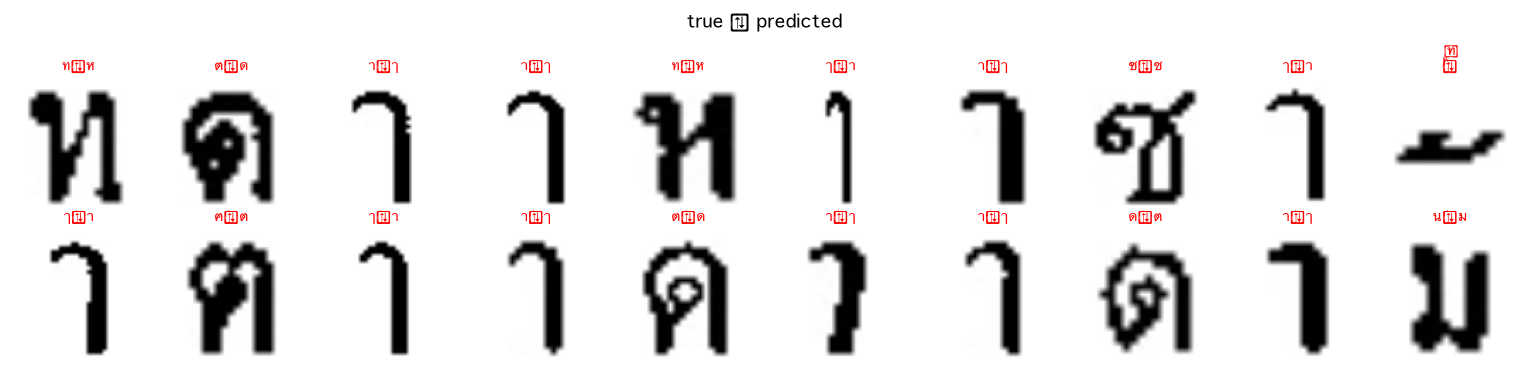

In [7]:
pred = np.load(ROOT / "experiments" / "hard_character" / "baseline" / "predictions.npz")
wrong = np.where(pred["y_true"] != pred["y_pred"])[0]
pick = np.random.default_rng(1).choice(wrong, min(20, len(wrong)), replace=False)
fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
for ax, k in zip(axes.flat, pick):
    ax.imshow(data.x[pred["ids"][k]], cmap="gray"); ax.axis("off")
    ax.set_title(f'{thai_char(data.classes[pred["y_true"][k]])}→{thai_char(data.classes[pred["y_pred"][k]])}',
                 fontsize=9, color="red")
plt.suptitle("true → predicted"); plt.tight_layout(); plt.show()

ต่อไปที่ `05_generalization.ipynb` ซึ่งเป็นการทดลองหลักของโปรเจกต์